> Introdução à Ciência dos Dados \
> Ciência da Computação – UFV/Florestal


* **Nome:** Gabriel Henrique Bramante Guimaraes
* **Matrícula:**  5794

# Aula Prática 04
## Visualização de Dados

**Objetivo:** Entender comandos para explorar dados visualmente por meio de gráficos.
**Pré-requisitos:** Linguagem de programação Python, estatística básica \
**Meta:** Ao final da prática, o aluno será capaz de analisar um conjunto de dados visualmente para ajudar na tomada de decisões.

----

In [5]:
### NÃO REMOVA ESSA CÉLULA! ####
!pip --no-cache-dir install --upgrade learntools_dados_ufv

!wget https://raw.githubusercontent.com/NESPEDUFV/CCF425-resources/master/p4/OnlineRetail.xlsx

  Preparing metadata (setup.py) ... done
  Created wheel for learntools_dados_ufv: filename=learntools_dados_ufv-1.0.14.6-py3-none-any.whl size=38836 sha256=c9f342b178a374370c0ce1e74ca631febdfad1c0c6f28d570a4871e8c82e0c8e
  Stored in directory: /tmp/pip-ephem-wheel-cache-4v9orlix/wheels/99/2c/be/f2927528c778f2f4fb4bea1fb5c5095194f4d877513d8fcc20
Successfully built learntools_dados_ufv
--2026-04-06 14:10:17--  https://raw.githubusercontent.com/NESPEDUFV/CCF425-resources/master/p4/OnlineRetail.xlsx
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23715344 (23M) [application/octet-stream]
Saving to: ‘OnlineRetail.xlsx’

OnlineRetail.xlsx   100%[===================>]  22.62M  --.-KB/s    in 0.1s    

2026-04-06 14:10:17 (168 MB/s) - ‘OnlineRetail.xlsx’ saved [237

In [1]:
#### Não altere essa célula!!! ####
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Roteiro

## Leitura dos dados
Veja os dados do arquivo `OnlineRetail.xlsx`.

Note que o arquivo é um Excel. A biblioteca consegue ler e o interpretar da mesma maneira que um CSV, como estamos acostumados.

Note que a função usada é a `read_excel` e não a `read_csv`.

É normal que demore um pouco, pois os arquivos em excel possuem muito mais recursos e dados armazenados do que um simples csv.

In [6]:
df = pd.read_excel('./OnlineRetail.xlsx')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


### Filtrar quantidades e preços unitários negativos

In [ ]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df

## Visualizar os dados

### Gráfico de Pontos (_Scatter Plot_)

In [71]:
dfExemplo = df[df["Quantity"] <= 10000]
dfExemplo = dfExemplo[dfExemplo["UnitPrice"] <= 6000]

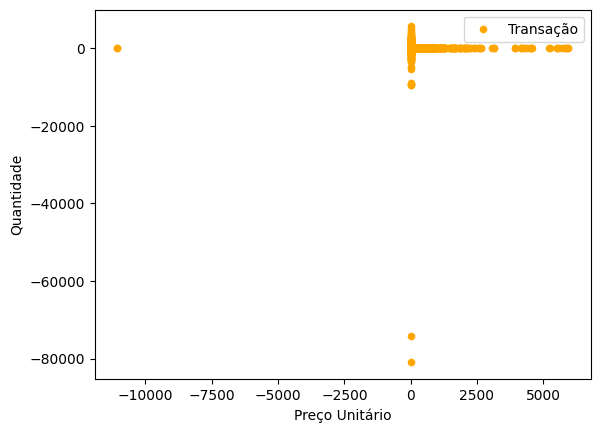

In [72]:
dfExemplo.plot(kind='scatter', x='UnitPrice', y='Quantity', color='orange', label='Transação')
# Adiciona um rótulo no eixo Y
plt.ylabel('Quantidade')
# Adiciona um rótulo no eixo X
plt.xlabel('Preço Unitário')

plt.show()

### Usar escala logarítmica nos dois eixos para melhorar a visualização
Também vamos gerar um gráfico colorindo e marcando por país

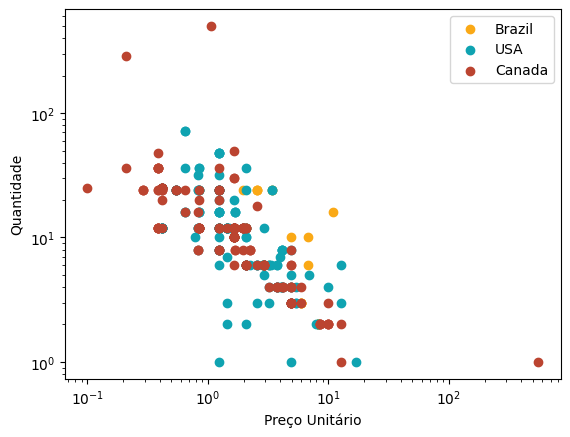

In [73]:
countries_colors = {
    'Brazil': '#FAA916',
    'USA': '#0FA3B1',
    'Canada': '#BB4430'
}

fig, ax = plt.subplots()
countries_data = list(map(
    lambda k: (
        k,
        df[df['Country'] == k]
        ),
    countries_colors.keys()
    ))
[ax.scatter(x=dataset['UnitPrice'], y=dataset['Quantity'], c=countries_colors[countries], label=countries) for (countries, dataset) in countries_data]

plt.ylabel('Quantidade')
plt.xlabel('Preço Unitário')
plt.xscale('log')
plt.yscale('log')
ax.legend() # Habilita a legenda das cores
plt.show()

### Usar um terceiro atributo para definir o tamanho do marcador

Veja o argumento `s` (de size) da função scatter

/usr/local/lib/python3.12/dist-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


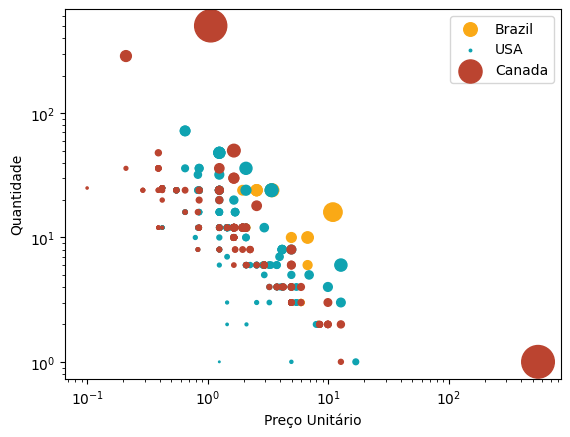

In [74]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

fig, ax = plt.subplots()
countries_data = list(map(lambda k: (k, df[df['Country'] == k]), countries_colors.keys()))
[ax.scatter(x=d['UnitPrice'], y=d['Quantity'], c=countries_colors[k], s=d['TotalPrice'],
            label=k) for (k, d) in countries_data]

plt.ylabel('Quantidade')
plt.xlabel('Preço Unitário')
plt.xscale('log')
plt.yscale('log')
ax.legend() # Habilita a legenda das cores
plt.show()

### Agrupar antes de exibir os gráficos
Agrupando pelo `InvoiceNo`

In [75]:
dfFiltrado = df[["TotalPrice","Quantity","InvoiceNo"]]

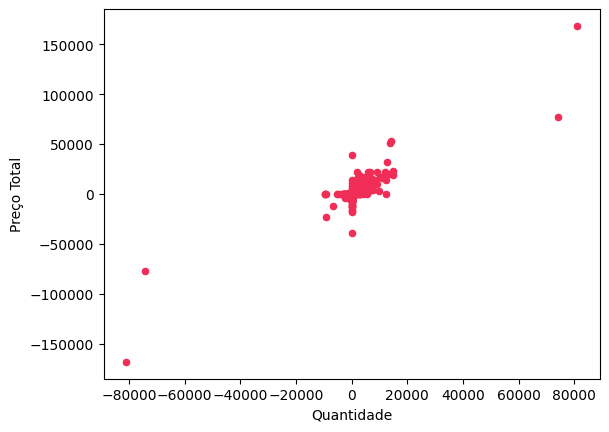

In [76]:
group_invoice = dfFiltrado.groupby('InvoiceNo')

group_invoice.sum().plot.scatter(x='Quantity', y='TotalPrice', c='#EF2D56')
plt.xlabel('Quantidade')
plt.ylabel('Preço Total')
plt.show()

### Gerar o mesmo gráfico anterior na escala logarítmica

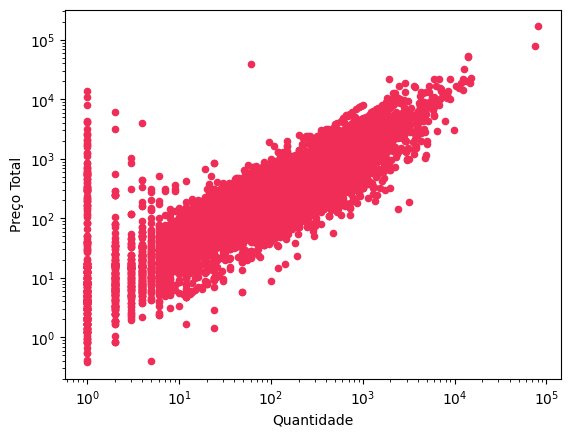

In [77]:
group_invoice = dfFiltrado.groupby('InvoiceNo')

group_invoice.sum().plot.scatter(x='Quantity', y='TotalPrice', c='#EF2D56')
plt.xlabel('Quantidade')
plt.ylabel('Preço Total')
plt.xscale('log')
plt.yscale('log')
plt.show()

### Plotar gráfico de linha para avaliar tendência.
Agrupar as compras por data e mostrar a quantidade de itens por data da compra.

In [78]:
dfFiltrado = df[["Quantity","InvoiceDate"]]

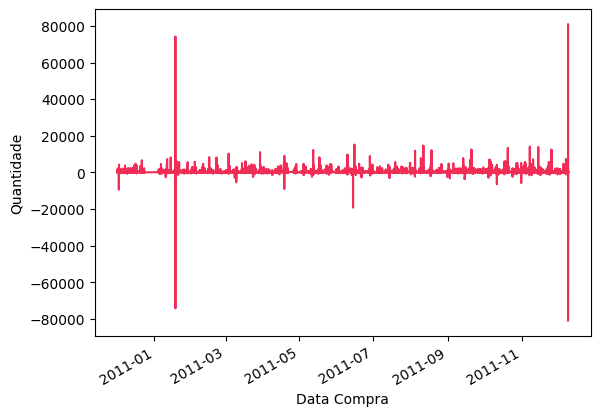

In [79]:
group_date = dfFiltrado.groupby('InvoiceDate')
group_date.sum()['Quantity'].plot(c='#EF2D56')
plt.xlabel('Data Compra')
plt.ylabel('Quantidade')
plt.show()

### Agrupar por Mês/Ano

In [80]:
group_month_year.sum()['Quantity']

NameError: name 'group_month_year' is not defined

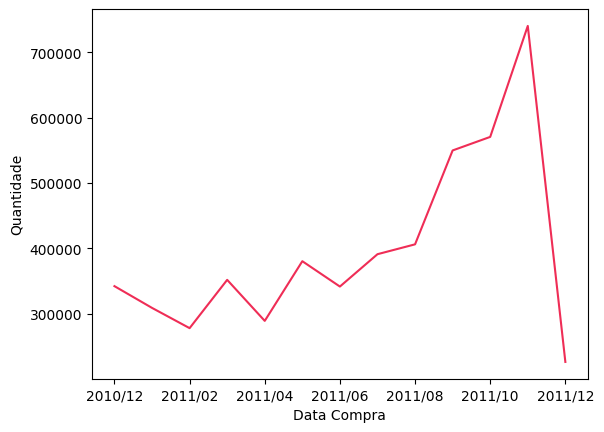

In [81]:
df['MonthYear'] = df['InvoiceDate'].dt.strftime('%Y/%m')
dfFiltrado = df[["Quantity","MonthYear"]]
group_month_year = dfFiltrado.groupby('MonthYear')
group_month_year.sum()['Quantity'].plot(c='#EF2D56')
plt.xlabel('Data Compra')
plt.ylabel('Quantidade')
plt.show()

### Plotar gráfico de barras para mostrar valores para atributos categóricos

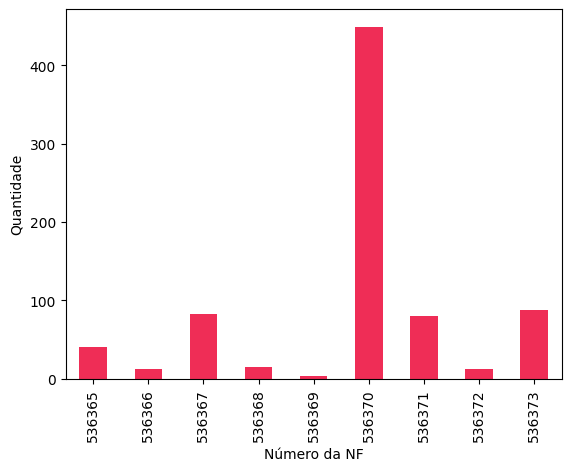

In [82]:
group_invoice.sum().iloc[0:9]['Quantity'].plot(kind='bar', color='#EF2D56')
plt.xlabel('Número da NF')
plt.ylabel('Quantidade')
plt.show()

### Plotar Histograma

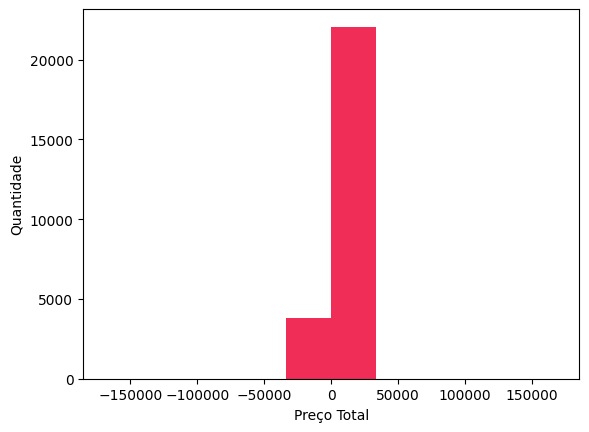

In [83]:
group_invoice.sum()['TotalPrice'].plot(kind='hist', color='#EF2D56')
plt.xlabel('Preço Total')
plt.ylabel('Quantidade')
plt.show()

### Filtrar para visualizar melhor a maioria
O gráfico acima possui uma concentração em valores menores mas possui alguns outliers com preço **muito** superior à maioria. Vamos resolver isso com um filtro.

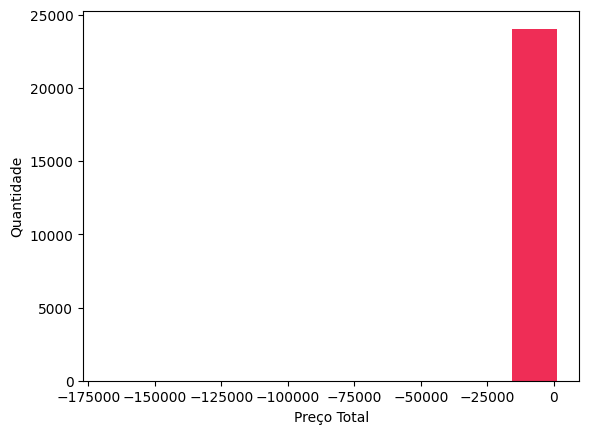

In [85]:
group_invoice.sum().loc[group_invoice.sum()['TotalPrice'] < 1000]['TotalPrice'].plot(kind='hist', color='#EF2D56')
plt.xlabel('Preço Total')
plt.ylabel('Quantidade')
plt.show()

### Alterar número de bins para ter mais detalhes

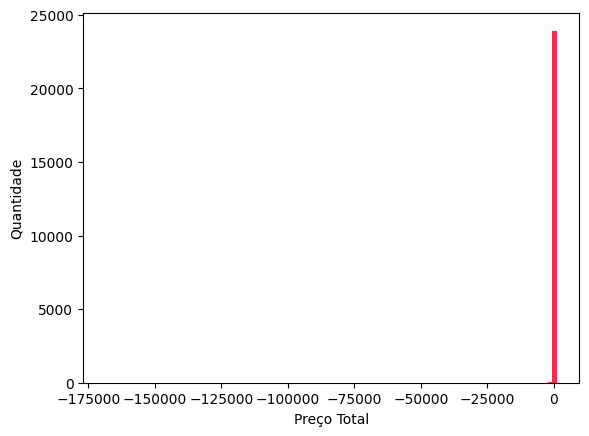

In [86]:
group_invoice.sum().loc[group_invoice.sum()['TotalPrice'] < 1000]['TotalPrice'].plot(kind='hist', color='#EF2D56', bins=100)
plt.xlabel('Preço Total')
plt.ylabel('Quantidade')
plt.show()

### Plotar um BoxPlot

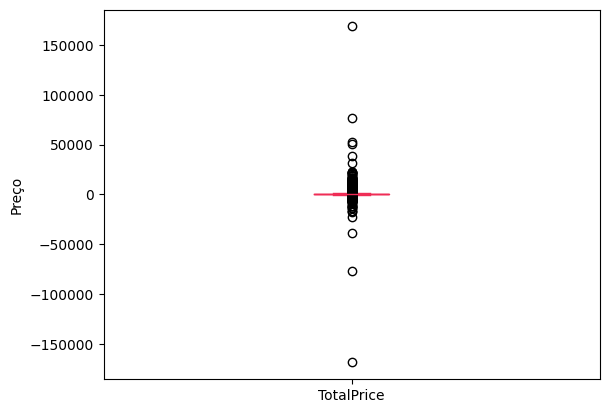

In [87]:
group_invoice.sum()['TotalPrice'].plot.box(color='#EF2D56')
plt.ylabel('Preço')
plt.show()

### Usar escala logarítmica para ver melhor

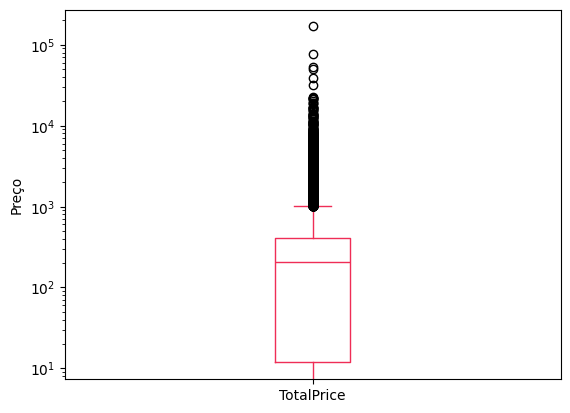

In [88]:
group_invoice.sum()['TotalPrice'].plot.box(color='#EF2D56')
plt.ylabel('Preço')
plt.yscale('log')
plt.show()

### Filtrar para valores menores

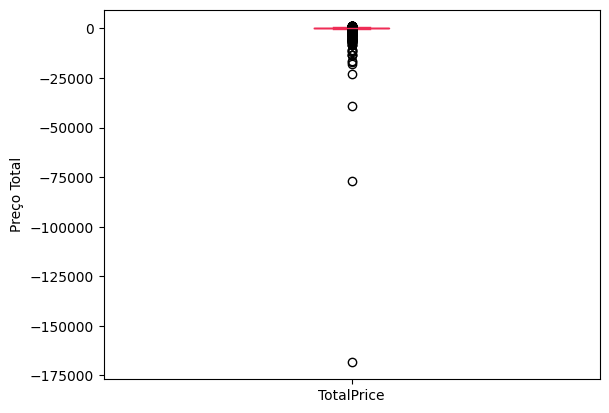

In [89]:
group_invoice.sum().loc[group_invoice.sum()['TotalPrice'] < 1000]['TotalPrice'].plot.box(color='#EF2D56')
plt.ylabel('Preço Total')
plt.show()

### Plotar boxplots agrupados por país

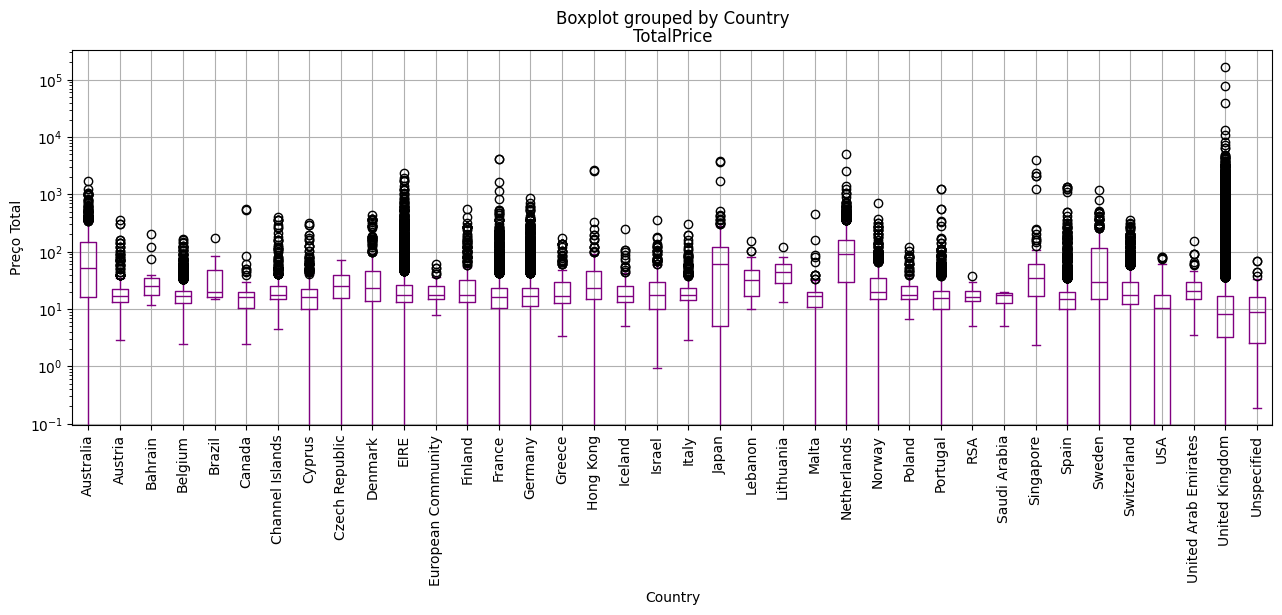

In [90]:
df.boxplot('TotalPrice', by='Country', rot=90, figsize=(15, 5), color='purple')
plt.ylabel('Preço Total')
plt.yscale('log')
plt.show()

# Exercícios

Execute e não remova a célula abaixo antes de iniciar os exercícios. Faça todas as atividades manipulando a variável `df`.

In [7]:
# Atribui o dataframe com o estado "original" em uma variável isolada
original_df = pd.read_excel('./OnlineRetail.xlsx')
df = original_df
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [53]:
dfclean = df[(df['UnitPrice'] >= 0) & (df['Quantity'] > 0)]
dfclean

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Faturamento
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


## 1. Faça um gráfico de barras mostrando a quantidade total vendida de cada um dos 10 primeiros produtos que aparecem no Dataframe.
Essa lista não possui correção automática.

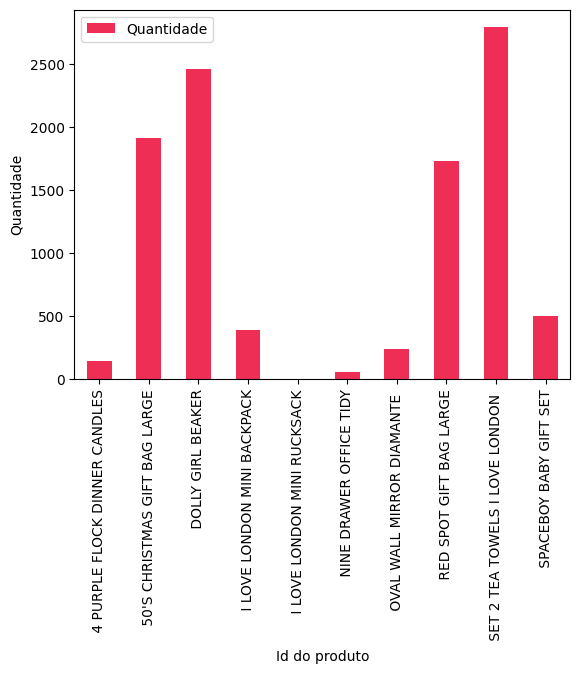

In [55]:
dfFiltrado = dfclean.groupby('Description').agg(Quantidade = ('Quantity', 'sum')).head(10)
dfFiltrado.plot(kind='bar', color='#EF2E56')
plt.xlabel('Id do produto')
plt.ylabel('Quantidade')
plt.show()

## 2. Faça um Boxplot dos preços unitários dos produtos. Considere somente os 10 produtos mais vendidos.
Essa lista não possui correção automática.

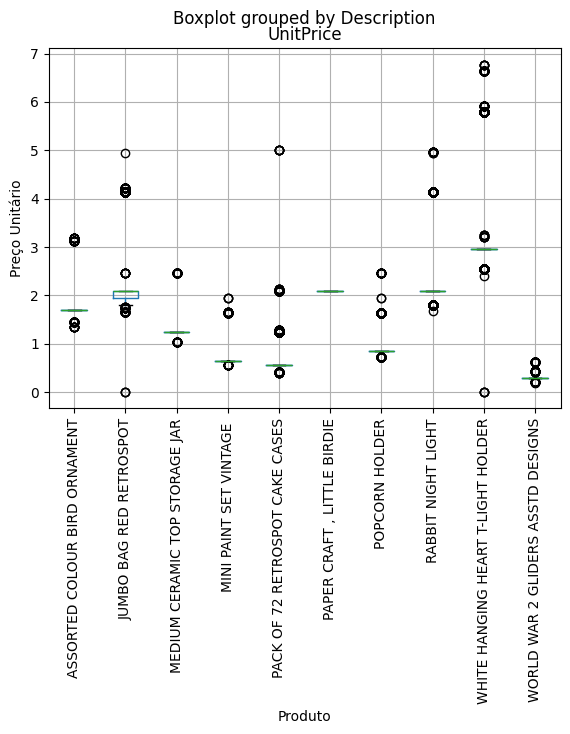

In [66]:
dfMax = dfclean.groupby('Description').agg(Quantidade=('Quantity', 'sum')).nlargest(10, 'Quantidade')

df_filtrado = dfclean[dfclean['Description'].isin(dfMax.index)]

df_filtrado.boxplot(column='UnitPrice', by='Description')

plt.xticks(rotation=90)
plt.xlabel('Produto')
plt.ylabel('Preço Unitário')

plt.show()

## 3. Faça um gráfico de linhas mostrando o faturamento (total de preços das vendas) por dia.
Essa lista não possui correção automática.

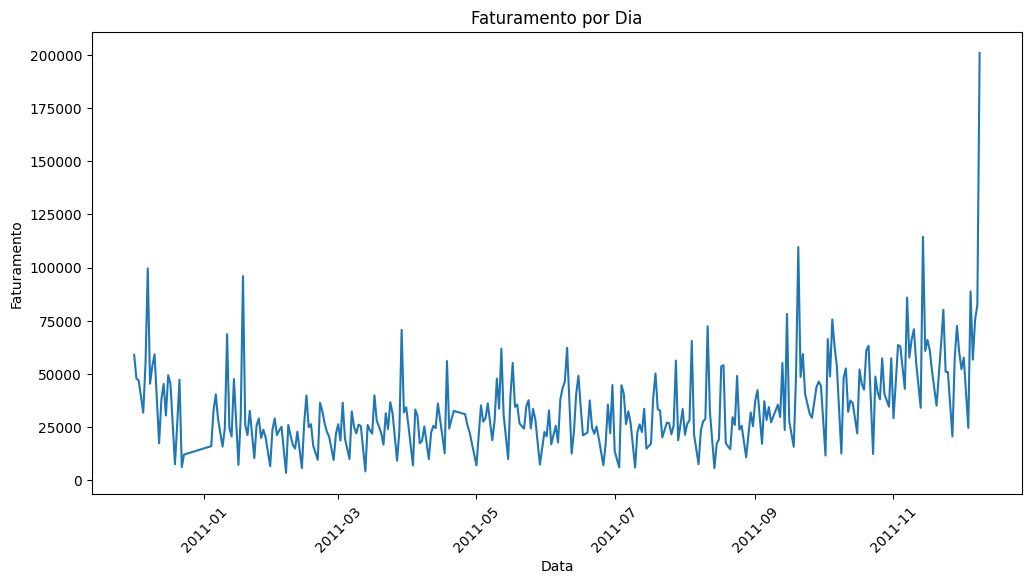

In [67]:
df_dia = (dfclean['Quantity'] * dfclean['UnitPrice']) \
.groupby(dfclean['InvoiceDate'].dt.date).sum()

df_dia = df_dia.sort_index()

plt.figure(figsize=(12,6))

plt.plot(df_dia.index, df_dia.values)

plt.title('Faturamento por Dia')
plt.xlabel('Data')
plt.ylabel('Faturamento')

plt.xticks(rotation=45)

plt.show()

## 4. Faça o histograma da média dos preços unitários dos produtos.
Essa lista não possui correção automática.

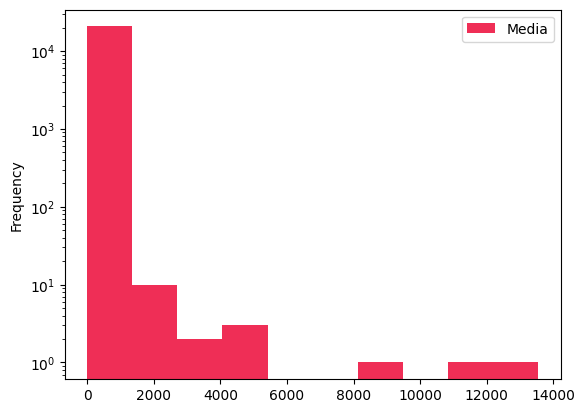

In [24]:
dfmediaprecos = dfclean.groupby('InvoiceNo').agg(Media = ('UnitPrice', 'mean'))
dfmediaprecos.plot(kind='hist', color='#EF2E56')
plt.yscale('log')
plt.show()

## 5. Faça dois gráficos de barras, sendo um da quantidade de compras e outro do total de faturamento por país.
Essa lista não possui correção automática.

Usei o copy, pois estava dando um warning

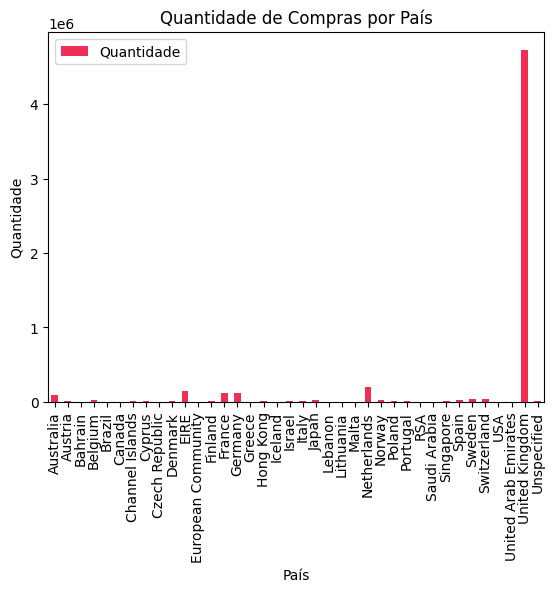

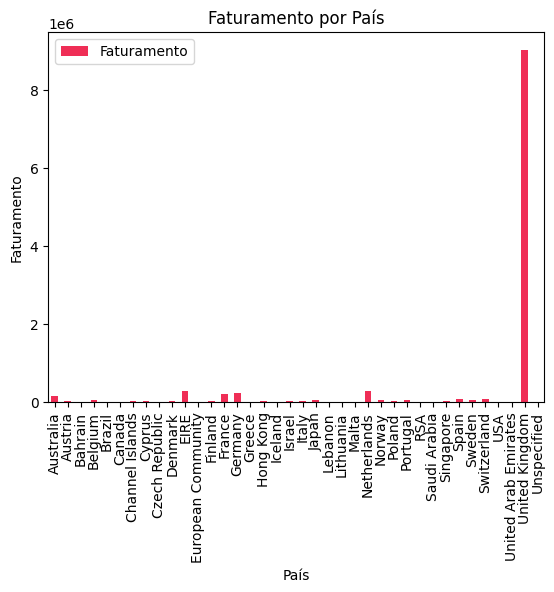

In [69]:
dfquantidade = dfclean.groupby('Country').agg(
    Quantidade=('Quantity', 'sum')
)

dfquantidade.plot(kind='bar', color='#EF2E56')
plt.xlabel('País')
plt.ylabel('Quantidade')
plt.title('Quantidade de Compras por País')
plt.show()

dfclean = dfclean.copy()
dfclean['Faturamento'] = dfclean['Quantity'] * dfclean['UnitPrice']

dffaturamento = dfclean.groupby('Country').agg(
    Faturamento=('Faturamento', 'sum')
)

dffaturamento.plot(kind='bar', color='#EF2E56')
plt.xlabel('País')
plt.ylabel('Faturamento')
plt.title('Faturamento por País')
plt.show()

## 6. Considerando os 100 produtos mais vendidos, é possível visualizar alguma diferença entre a distribuição dos preços unitários desses produtos ao se comparar os países “Australia” e “United Kingdom”? Faça um ou mais gráficos para ajudar a responder.
Essa lista não possui correção automática.

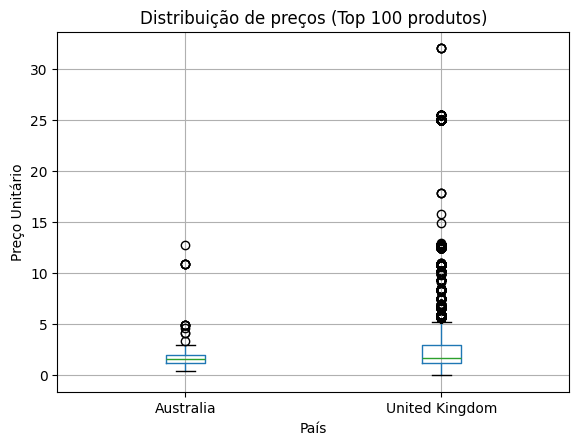

In [39]:
df_top100 = dfclean.groupby('Description').agg(Quantidade=('Quantity', 'sum')).nlargest(100, 'Quantidade')
df_filtrado = dfclean[dfclean['Description'].isin(df_top100.index)]
df_filtrado = df_filtrado[(df_filtrado['Country'] == 'Australia') | (df_filtrado['Country'] == 'United Kingdom')]
df_filtrado.boxplot(column='UnitPrice', by='Country')

plt.title('Distribuição de preços (Top 100 produtos)')
plt.suptitle('')
plt.xlabel('País')
plt.ylabel('Preço Unitário')

plt.show()


Nesse gráfico é possível visualizar a diferença tanto da média quanto a diferença dos preços nós dois países, que mostra Reino Unido com preços bem mais variados sendo comprados. Acredito por conta da quantidade muito maior de vendas, o que pode ser um cuidado a ser tomado.

## 7. Faça um gráfico de barras, de linhas, histograma e boxplot usando a biblioteca `seaborn`.
Essa lista não possui correção automática.

A biblioteca já está importada pelo nome de `sns`. Vai um gráfico de exemplo abaixo ;)

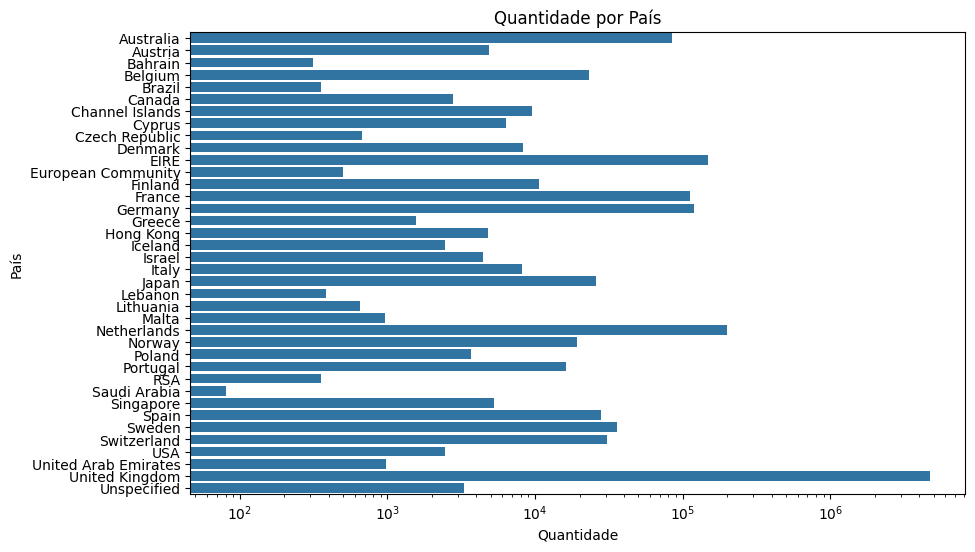

In [41]:
country_group_sum = dfclean.groupby('Country').sum(numeric_only=True).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=country_group_sum, x='Quantity', y='Country')

plt.xscale('log')
plt.title('Quantidade por País')
plt.xlabel('Quantidade')
plt.ylabel('País')

plt.show()

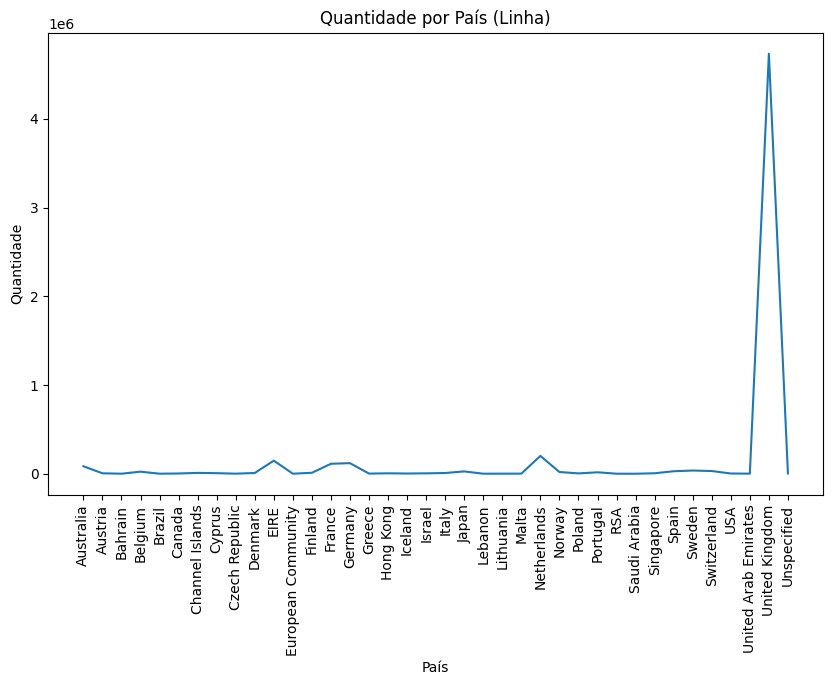

In [42]:
plt.figure(figsize=(10,6))
sns.lineplot(data=country_group_sum, x='Country', y='Quantity')

plt.xticks(rotation=90)
plt.title('Quantidade por País (Linha)')
plt.xlabel('País')
plt.ylabel('Quantidade')

plt.show()

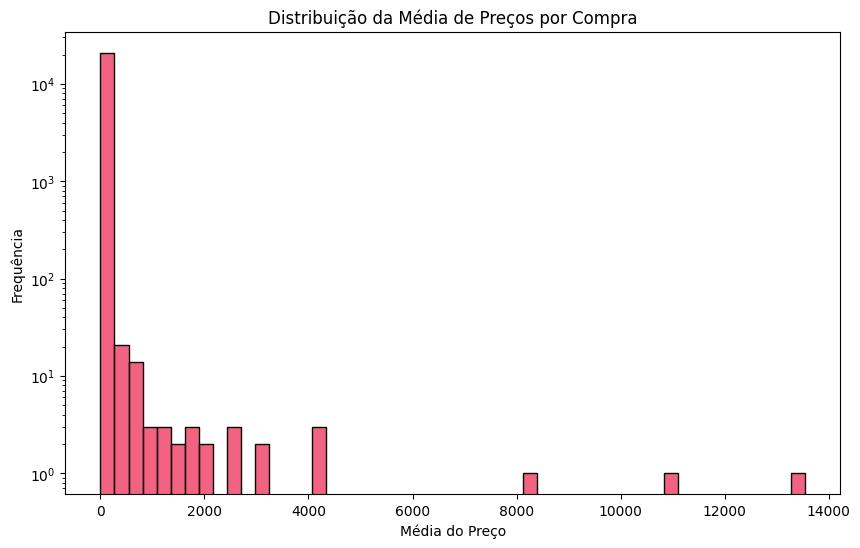

In [51]:
plt.figure(figsize=(10,6))

sns.histplot(data=dfmediaprecos, x='Media', bins=50, color='#EF2E56')

plt.yscale('log')
plt.title('Distribuição da Média de Preços por Compra')
plt.xlabel('Média do Preço')
plt.ylabel('Frequência')

plt.show()

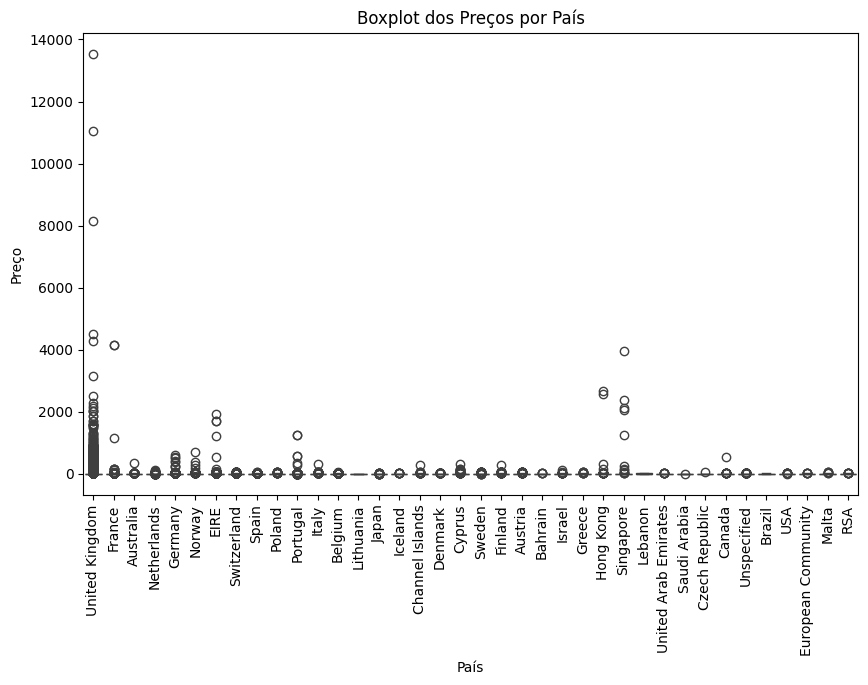

In [44]:
plt.figure(figsize=(10,6))
sns.boxplot(data=dfclean, x='Country', y='UnitPrice')

plt.xticks(rotation=90)
plt.title('Boxplot dos Preços por País')
plt.xlabel('País')
plt.ylabel('Preço')

plt.show()

## 7. Faça uma breve análise e comparação dos plots feitos com o `seaborn` e com o `matplotlib`.
Qual você gostou mais? Viu alguma diferença em performance neles?

Resposta da 7.: Achei o matplotlib mais facil de entender, porém achei o seaborn mais prático de utilizar, o matplotlib apresenta maior legibilidade no processo de construção, enquanto o seaborn se destaca pela praticidade. Em questão dos gráficos achei bem parecidos. O matplotlib, na minha máquina rodou um pouco mais rápido.